# Re training the Model with a Larger Dataset

In [120]:
! pip install --only-binary :all: umap-learn

In [121]:
! pip install --upgrade pip
! pip install pandas
! pip install scikit-learn
! pip install hdbscan 
! pip install matplotlib
! pip install --only-binary :all: umap-learn
! pip install seaborn
! pip install plotly

# Imports

In [122]:
import re
import sys
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

# Use GCP pipeline so features match production exactly
gcp_dir = os.path.join(os.getcwd(), 'GCP-VM-Pipeline ')
if gcp_dir not in sys.path:
    sys.path.insert(0, gcp_dir)

from pipeline import parse_nginx_lines, make_5min_windows
from hdbscan import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Imports OK")

Imports OK


# Load + Data Cleanup

In [123]:
DATASETS = 'Datasets'
PREFIX_RE = re.compile(r'^/[^:]+:')  # strips "/var/log/nginx/access.log.1:" prefix

# shared request parser (same logic as pipeline)
_REQ_RE = re.compile(r"^(?P<method>[A-Z]+)\s+(?P<path>\S+)\s+HTTP\/")
def _parse_req(line):
    m = _REQ_RE.search(str(line))
    if not m: return ("UNK", "/")
    path = m.group("path").split("?")[0]
    return m.group("method"), re.sub(r"\d+", "0", path)

# ── 1. Standard nginx logs ─────────────────────────────────────────────────────
NGINX_LOGS = [
    'access_last10days(BunnyCDN).log',
    'nginx_access_16Jan(No CDN).log',
    'nginx_access_21Feb-7Mar_2026.log',
    'nginx_errors_21Feb-7Mar_2026.log'
]
dfs = []
for fname in NGINX_LOGS:
    with open(os.path.join(DATASETS, fname), 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    part = parse_nginx_lines(lines)
    print(f'{fname}: {len(part):,} rows')
    dfs.append(part)

# ── 2. Cloudflare nginx log (has "filepath:" prefix on each line) ──────────────
CF_LOG = os.path.join(DATASETS, 'nginx_access_19Dec-27Dec_2025(Cloudflare).log')
with open(CF_LOG, 'r', encoding='utf-8', errors='ignore') as f:
    cf_lines = [PREFIX_RE.sub('', line) for line in f.readlines()]
df_cf = parse_nginx_lines(cf_lines)
print(f'nginx_access_19Dec-27Dec_2025(Cloudflare).log: {len(df_cf):,} rows')
dfs.append(df_cf)

# # ── 3. honeypot_logs.csv (CSV with header; IP column has filepath prefix) ──────
# CSV_LOG = os.path.join(DATASETS, 'honeypot_logs.csv')
# raw = pd.read_csv(CSV_LOG, header=0, encoding='utf-8-sig')
# raw["client_ip"] = raw["Log Source and Client IP"].astype(str).str.split(":").str[-1].str.strip()
# ts = raw["Timestamp"].astype(str).str.strip("[] ").str.strip()
# raw["Timestamp"] = pd.to_datetime(ts, format="%d/%b/%Y:%H:%M:%S", errors="coerce", utc=True)
# raw["HTTP Status Code"] = pd.to_numeric(raw["HTTP Status Code"], errors="coerce")
# raw["Response size (bytes)"] = pd.to_numeric(raw["Response size (bytes)"], errors="coerce").fillna(0)
# raw[["http_method", "http_path"]] = raw["HTTP Request Line"].apply(lambda x: pd.Series(_parse_req(x)))
# df_csv = raw.dropna(subset=["Timestamp", "client_ip", "HTTP Status Code"])[
#     ["client_ip", "Timestamp", "HTTP Status Code", "Response size (bytes)", "http_method", "http_path", "User-Agent"]
# ].reset_index(drop=True)
# print(f'honeypot_logs.csv: {len(df_csv):,} rows')
# dfs.append(df_csv)

# ── 4. Combine all datasets ────────────────────────────────────────────────────
df = pd.concat(dfs, ignore_index=True)
df = df.sort_values('Timestamp').reset_index(drop=True)

print(f'\nCombined total: {len(df):,} rows')
print(f'Date range:     {df["Timestamp"].min()} → {df["Timestamp"].max()}')
df.head(3)

access_last10days(BunnyCDN).log: 10,431 rows
nginx_access_16Jan(No CDN).log: 300 rows
nginx_access_21Feb-7Mar_2026.log: 34,825 rows
nginx_errors_21Feb-7Mar_2026.log: 0 rows
nginx_access_19Dec-27Dec_2025(Cloudflare).log: 3,621 rows

Combined total: 49,177 rows
Date range:     2025-12-14 03:42:50+00:00 → 2026-03-07 10:16:47+00:00


,client_ip,Timestamp,HTTP Status Code,Response size (bytes),http_method,http_path,User-Agent
0,194.180.49.173,2025-12-14 03:42:50+00:00,404,147,GET,/api/.env,python-httpx/0.28.1
1,194.180.49.173,2025-12-14 04:06:11+00:00,404,147,GET,/api/.env,python-httpx/0.28.1
2,172.64.198.125,2025-12-14 04:27:51+00:00,404,147,GET,/api/.env,python-httpx/0.28.1


# parse request line into method + path 

# Break Requests down into sessions

In [124]:
windows = make_5min_windows(df)
print(f'5-min windows: {len(windows):,}')
windows.head(3)

5-min windows: 4,133


,client_ip,window_start,request_count,unique_paths,unique_methods,status_200,status_401,status_403,status_404,status_429,status_500,avg_response_size,std_response_size,paths,uas,ratio_4xx,ratio_429,ratio_5xx,path_text
0,1.24.16.102,2026-03-05 16:05:00+00:00,1,1,1,1,0,0,0,0,0,1708.0,0.0,[/],[Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....,0.0,0.0,0.0,/
1,1.24.16.50,2026-02-28 10:15:00+00:00,2,1,1,2,0,0,0,0,0,1708.0,0.0,"[/, /]",[Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....,0.0,0.0,0.0,/ /
2,1.252.194.4,2026-02-28 20:30:00+00:00,2,1,1,0,0,0,0,0,0,169.0,0.0,"[/, /]","[-, -]",0.0,0.0,0.0,/ /


# Train - Test Data Split

In [125]:
# Time-based split — hold out the most recent 20% of windows for drift testing.
# Temporal ordering is critical: the model trains on older traffic and we
# measure centroid drift against newer traffic, mirroring production behaviour.

HOLDOUT_FRAC = 0.20

windows_sorted = windows.sort_values("window_start").reset_index(drop=True)
cutoff_idx = int(len(windows_sorted) * (1 - HOLDOUT_FRAC))
cutoff_time = windows_sorted.iloc[cutoff_idx]["window_start"]

train_data = windows_sorted.iloc[:cutoff_idx].copy().reset_index(drop=True)
test_data  = windows_sorted.iloc[cutoff_idx:].copy().reset_index(drop=True)

print(f"Total windows   : {len(windows_sorted):,}")
print(f"Train windows   : {len(train_data):,}  (up to {cutoff_time})")
print(f"Test  windows   : {len(test_data):,}  (after {cutoff_time})")
print(f"Test date range : {test_data['window_start'].min()}  →  {test_data['window_start'].max()}")

Total windows   : 4,133
Train windows   : 3,306  (up to 2026-03-03 17:40:00+00:00)
Test  windows   : 827  (after 2026-03-03 17:40:00+00:00)
Test date range : 2026-03-03 17:40:00+00:00  →  2026-03-07 10:15:00+00:00


# Feature Pre-processing (Scaling and Vectorisation)

In [126]:
# Feature engineering — must match production pipeline exactly
num_cols = [
    "request_count", "unique_paths", "unique_methods",
    "status_200", "status_401", "status_403", "status_404",
    "status_429", "status_500",
    "avg_response_size", "std_response_size",
    "ratio_4xx", "ratio_429", "ratio_5xx",
]

train_data["path_text"] = train_data["paths"].apply(lambda xs: " ".join(map(str, xs)))

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    token_pattern=r"[^\/\s]+",
    min_df=2,
)
scaler = StandardScaler()

X_txt = tfidf.fit_transform(train_data["path_text"].fillna(""))
X_num = scaler.fit_transform(train_data[num_cols].fillna(0))
X_train = hstack([X_txt, csr_matrix(X_num)])

print(f'X_train shape: {X_train.shape}')

X_train shape: (3306, 514)


# Pick best K based off silhoette score

In [127]:
import numpy as np
import pandas as pd
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ---- search space (tune ranges to your traffic volume) ----
MCS = [10, 20, 30, 50, 80, 120, 200]
MS  = [None, 5, 10, 20]

rows = []

for mcs in MCS:
    for ms in MS:
        hdb = HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            # If X_train is TF-IDF / sparse text, cosine is usually a better default than euclidean.
            # If X_train is dense numeric, keep euclidean.
            metric="cosine" if hasattr(X_train, "tocsr") or "scipy.sparse" in str(type(X_train)) else "euclidean"
        )

        labels = hdb.fit_predict(X_train)

        mask = labels != -1
        n_points = len(labels)
        n_noise = int((~mask).sum())
        noise_ratio = n_noise / n_points

        # clusters excluding noise
        n_clusters = len(set(labels[mask])) if mask.any() else 0

        # HDBSCAN stability (higher = more stable clusters)
        # cluster_persistence_ exists after fit; empty when no clusters
        stability_mean = float(np.mean(hdb.cluster_persistence_)) if n_clusters > 0 else 0.0

        sil = np.nan
        db = np.nan

        # Score only on non-noise points, and only if >=2 clusters
        if mask.sum() > 1 and n_clusters >= 2:
            X_eval = X_train[mask]
            y_eval = labels[mask]

            # silhouette supports sparse input (OK)
            sil = float(silhouette_score(X_eval, y_eval))

            # Davies-Bouldin needs dense; fall back carefully
            if hasattr(X_eval, "toarray") and X_eval.shape[1] < 2000:
                X_dense = X_eval.toarray()
            else:
                # If you have a dense numeric representation for high-dim sparse text,
                # use it here. Otherwise, skip DB.
                X_dense = X_num_train[mask] if "X_num_train" in globals() else None

            if X_dense is not None:
                db = float(davies_bouldin_score(X_dense, y_eval))

        rows.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": int(n_clusters),
            "noise_ratio": float(noise_ratio),
            "silhouette": sil,
            "davies_bouldin": db,
            "stability_mean": stability_mean,
        })

results = pd.DataFrame(rows)

# ---- pick "best" config with an analyst-friendly objective ----
# We want:
# - stable clusters (maximize stability_mean)
# - not too many clusters (target range)
# - not all noise
# - silhouette helps but isn't the main boss
TARGET_CLUSTERS = 20

def objective(r):
    # penalties
    cluster_penalty = abs(r["n_clusters"] - TARGET_CLUSTERS)
    noise_penalty = 0 if (0.2 <= r["noise_ratio"] <= 0.9) else 5  # keep in a plausible range
    sil_bonus = 0 if np.isnan(r["silhouette"]) else -0.5 * r["silhouette"]  # higher sil => lower objective
    # main term: prefer higher stability
    return (-2.0 * r["stability_mean"]) + cluster_penalty + noise_penalty + sil_bonus

results["objective"] = results.apply(objective, axis=1)
best = results.sort_values("objective").iloc[0]

print("Best config:")
print(best.to_string())

# Optional: show the whole table sorted
results.sort_values(["objective", "stability_mean"], ascending=[True, False])


Best config:
min_cluster_size    50.000000
min_samples         20.000000
n_clusters          20.000000
noise_ratio          0.349062
silhouette           0.691324
davies_bouldin       1.000010
stability_mean       0.272751
objective           -0.891164


,min_cluster_size,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,stability_mean,objective
15,50,20.0,20,0.349062,0.691324,1.000010,0.272751,-0.891164
14,50,10.0,21,0.318512,0.656818,1.114394,0.259548,0.152494
12,50,NaN,18,0.395947,0.760775,1.957993,0.303321,1.012971
13,50,5.0,22,0.294011,0.606238,1.413388,0.247538,1.201806
8,30,NaN,27,0.299153,0.737024,2.006504,1.000000,4.631488
11,30,20.0,28,0.279794,0.756869,0.972212,1.000000,5.621565
10,30,10.0,30,0.247429,0.720758,1.154990,1.000000,7.639621
16,80,NaN,11,0.461585,0.687849,1.819421,0.370351,7.915375
17,80,5.0,11,0.394737,0.449847,1.515900,0.370351,8.034375
9,30,5.0,31,0.266485,0.677996,1.342713,1.000000,8.661002


# Fit Model

In [128]:
from hdbscan import HDBSCAN

# If you ran the previous cell, you already have:
# - results (DataFrame)
# - best (Series with min_cluster_size + min_samples)

best_mcs = 50 # int(best["min_cluster_size"])
best_ms  = 5   # None if pd.isna(best["min_samples"]) else int(best["min_samples"])

# Match the metric choice you used in the sweep
best_metric = "cosine" if hasattr(X_train, "tocsr") or "scipy.sparse" in str(type(X_train)) else "euclidean"

hdb = HDBSCAN(
    min_cluster_size=best_mcs,
    min_samples=best_ms,
    metric=best_metric,
    prediction_data=True
)

train_data["cluster"] = hdb.fit_predict(X_train)

# Cluster counts (includes -1 noise at the top)
train_data["cluster"].value_counts().sort_index()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/hdbscan/hdbscan_.py:1329: UserWarning: Metric cosine not supported for prediction data!
  warn("Metric {} not supported for prediction data!".format(self.metric))


cluster
-1     972
 0      56
 1      75
 2      97
 3      73
 4      60
 5      60
 6      61
 7      97
 8      69
 9      76
 10     84
 11    133
 12     50
 13     76
 14    201
 15    101
 16    232
 17    129
 18     85
 19     63
 20    396
 21     60
Name: count, dtype: int64

In [129]:
vc = train_data["cluster"].value_counts()
out = pd.DataFrame({
    "count": vc,
    "pct": (vc / vc.sum()).round(4)
}).sort_index()

print("Noise (-1):", int(out.loc[-1, "count"]) if -1 in out.index else 0)
out


Noise (-1): 972


,count,pct
cluster,,
-1,972,0.2940
0,56,0.0169
1,75,0.0227
2,97,0.0293
3,73,0.0221
4,60,0.0181
5,60,0.0181
6,61,0.0185
7,97,0.0293


# Interpret Clusters

In [130]:
for c in sorted(train_data["cluster"].unique()):
    subset = train_data[train_data["cluster"] == c]
    # flatten paths
    paths = pd.Series([p for ps in subset["paths"] for p in ps])
    print(f"\nCluster {c} | n={len(subset)}")
    print("Top paths:")
    print(paths.value_counts().head(10))
    print("Avg request_count:", subset["request_count"].mean())
    print("Avg ratio_4xx:", subset["ratio_4xx"].mean())



Cluster -1 | n=972
Top paths:
/api/auth/login             1842
/                            626
/favicon.ico                 107
/0.php                        77
/.env                         61
/Dr0v                         55
/SDK/webLanguage              49
/actuator/gateway/routes      46
/service/api-docs/            45
/wp-login.php                 38
Name: count, dtype: int64
Avg request_count: 8.08641975308642
Avg ratio_4xx: 0.00830675017453224

Cluster 0 | n=56
Top paths:
/cgi-bin/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/bin/sh                               47
google.com:0                                                                                    34
/cgi-bin/%%0%0%%0%0/%%0%0%%0%0/%%0%0%%0%0/%%0%0%%0%0/%%0%0%%0%0/%%0%0%%0%0/%%0%0%%0%0/bin/sh     4
/contract/private/submit-order                                                                   2
/hello.world                                                                                     2
Name: count, dtype

In [131]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# X_train is the hstacked TF-IDF + numeric
X_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train

reducer = umap.UMAP(
    n_components=3,
    random_state=42,
    metric="cosine"
)

embedding = reducer.fit_transform(X_dense)

train_data["umap_x"] = embedding[:, 0]
train_data["umap_y"] = embedding[:, 1]
train_data["umap_z"] = embedding[:, 2]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


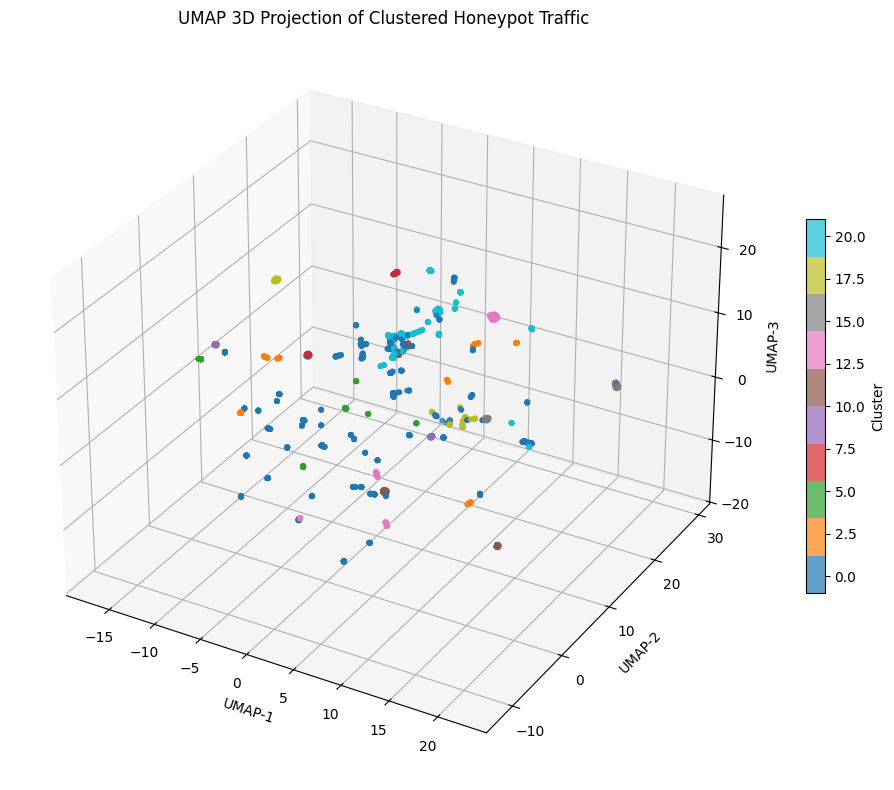

In [132]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    train_data["umap_x"],
    train_data["umap_y"],
    train_data["umap_z"],
    c=train_data["cluster"],
    cmap="tab10",
    s=10,
    alpha=0.7,
)

ax.set_title("UMAP 3D Projection of Clustered Honeypot Traffic")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_zlabel("UMAP-3")
fig.colorbar(scatter, ax=ax, label="Cluster", shrink=0.5)
plt.tight_layout()
plt.show()

In [133]:
import plotly.graph_objects as go
import numpy as np
import umap.umap_ as umap

# --- Ensure 3-D UMAP embedding exists ---
if "umap_z" not in train_data.columns:
    print("umap_z not found — computing 3-D UMAP embedding...")
    X_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
    reducer = umap.UMAP(n_components=3, random_state=42, metric="cosine")
    embedding = reducer.fit_transform(X_dense)
    train_data["umap_x"] = embedding[:, 0]
    train_data["umap_y"] = embedding[:, 1]
    train_data["umap_z"] = embedding[:, 2]
    print("Done.")

# --- Resolve cluster name mapping (most accurate source wins) ---
if "cluster_label" in train_data.columns:
    # cluster_label already merged into train_data
    name_map = train_data.groupby("cluster")["cluster_label"].first().to_dict()
    print("Using cluster_label from train_data")
else:
    try:
        # cluster_labels DataFrame defined later in notebook — use it if available
        name_map = cluster_labels.set_index("cluster")["cluster_label"].to_dict()
        print("Using cluster_labels DataFrame")
    except NameError:
        # Fallback: hardcoded names (run cells after LLM labelling for accurate names)
        name_map = {
            -1: "Noise",
             0: "Secrets Discovery (.env)",
             1: "WordPress Admin Enum",
             2: "IoT Device Login Scan",
             3: "Secrets Discovery (.env)",
             4: "Generic Login Discovery",
             5: "Generic Login Discovery",
             6: "Generic Login Discovery",
             7: "Swagger/OpenAPI Enum",
             8: "WordPress Admin Enum",
             9: "WordPress Admin Enum",
            10: "Generic Login Discovery",
            11: "PHPUnit RCE Probing",
            12: "WordPress Admin Enum",
            13: "WordPress Admin Enum",
        }
        print("Warning: cluster_labels not yet defined — using fallback names. Run LLM labelling cells first for accurate names.")

unique_clusters = sorted(train_data["cluster"].unique())

# Colour map — grey/transparent for noise, tab20 for real clusters
named_clusters = [c for c in unique_clusters if c != -1]
colors = plt.cm.tab20(np.linspace(0, 1, max(len(named_clusters), 1)))
color_map = {}
idx = 0
for c in unique_clusters:
    if c == -1:
        color_map[c] = "rgba(180,180,180,0.25)"
    else:
        r, g, b, _ = colors[idx]
        color_map[c] = f"rgba({int(r*255)},{int(g*255)},{int(b*255)},0.85)"
        idx += 1

fig = go.Figure()

for cluster_id in unique_clusters:
    mask = train_data["cluster"] == cluster_id
    subset = train_data[mask]

    label = name_map.get(cluster_id, f"Cluster {cluster_id}")
    legend_name = f"{'Noise' if cluster_id == -1 else f'C{cluster_id}'}: {label}"
    point_size  = 2 if cluster_id == -1 else 4

    # Build hover columns (use whichever exist)
    custom_cols = []
    if "ip" in subset.columns:
        custom_cols.append("ip")
    for col in ["request_count", "unique_paths", "path_text"]:
        if col in subset.columns:
            custom_cols.append(col)

    customdata = subset[custom_cols].copy()
    if "path_text" in customdata.columns:
        customdata["path_text"] = customdata["path_text"].str[:120]

    hover_lines = [f"<b>{legend_name}</b>"]
    for i, col in enumerate(custom_cols):
        hover_lines.append(f"{col.replace('_', ' ').title()}: %{{customdata[{i}]}}")
    hover_lines += ["UMAP: (%{x:.2f}, %{y:.2f}, %{z:.2f})", "<extra></extra>"]

    fig.add_trace(go.Scatter3d(
        x=subset["umap_x"],
        y=subset["umap_y"],
        z=subset["umap_z"],
        mode="markers",
        name=legend_name,
        marker=dict(size=point_size, color=color_map[cluster_id], line=dict(width=0)),
        customdata=customdata.values,
        hovertemplate="<br>".join(hover_lines),
    ))

fig.update_layout(
    title=dict(text="Honeypot Traffic Clusters — UMAP 3D", font=dict(size=20, color="white"), x=0.5),
    scene=dict(
        xaxis=dict(title="UMAP-1", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        yaxis=dict(title="UMAP-2", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        zaxis=dict(title="UMAP-3", backgroundcolor="rgb(10,10,20)", gridcolor="rgba(100,100,100,0.4)", showbackground=True),
        bgcolor="rgb(10,10,20)",
    ),
    paper_bgcolor="rgb(10,10,20)",
    plot_bgcolor="rgb(10,10,20)",
    font=dict(color="white"),
    legend=dict(title="Clusters", font=dict(size=10), itemsizing="constant"),
    margin=dict(l=0, r=0, t=50, b=0),
    width=1200,
    height=850,
)

fig.show()
fig.write_html("honeypot_clusters_3d.html")
print("Saved → honeypot_clusters_3d.html")

Using cluster_labels DataFrame


Saved → honeypot_clusters_3d.html


In [134]:
from sklearn.preprocessing import normalize

endpoint_counts = (
    train_data.explode("paths")
    .groupby(["cluster", "paths"])
    .size()
    .unstack(fill_value=0)
)

# Optional: only show top 20 paths
top_paths = endpoint_counts.sum().sort_values(ascending=False).head(20).index
heatmap_data = endpoint_counts[top_paths]


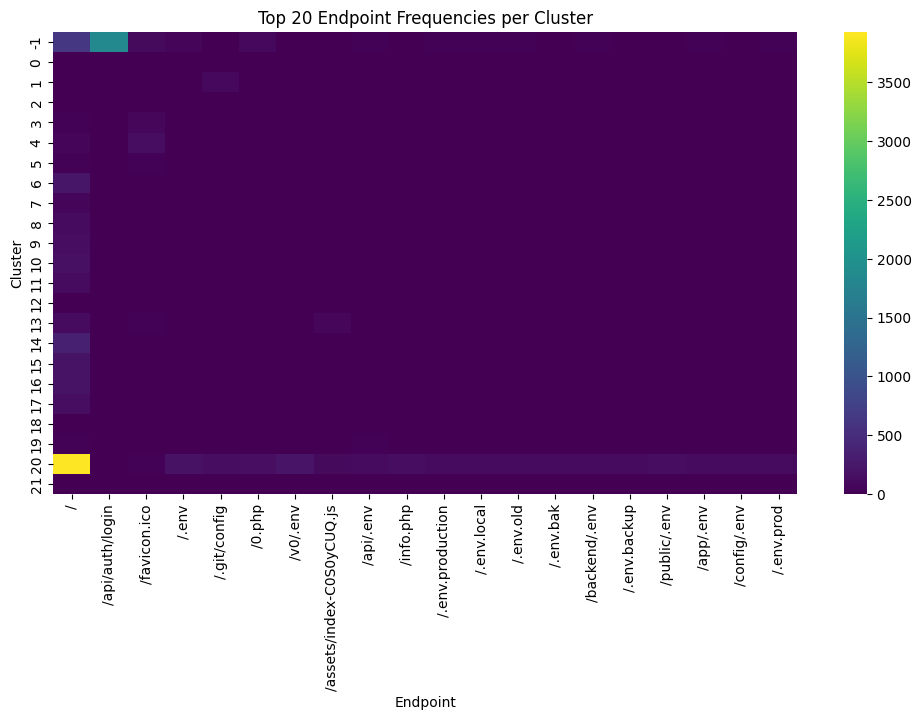

In [135]:
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Top 20 Endpoint Frequencies per Cluster")
plt.xlabel("Endpoint")
plt.ylabel("Cluster")
plt.show()


# Labelling Clusters

In [136]:
LABEL_RULES = [
    {
        "label": "WordPress exploitation / admin enumeration",
        "patterns": [
            r"^/wp-admin\b", r"^/wp-login\.php$", r"^/wp-includes\b",
            r"autoload_classmap\.php", r"classwithtostring\.php", r"wp-conflg\.php",
            r"xmlrpc\.php", r"wp-json", r"rest-api", r"colour\.php",
            r"wp-content/themes", r"wp-content/uploads", r"wp-content/plugins",
            r"wp-editor\.php", r"wp-the\.php", r"wp-admin\.php"
        ],
        "min_hits": 3
    },
    {
        "label": "PHPUnit RCE probing (eval-stdin.php)",
        "patterns": [r"phpunit", r"eval-stdin\.php"],
        "min_hits": 2
    },
    {
        "label": "Secrets discovery (.env harvesting)",
        "patterns": [
            r"\.env(\.|$)", r"/api/\.env", r"/apis/\.env", r"/nodeapi/\.env",
            r"\.env\.production", r"\.env\.local", r"\.env\.backup",
            r"\.env\.bak", r"\.env\.old", r"\.env\.staging",
            r"/backend/\.env", r"/app/\.env", r"/config/\.env",
            r"/public/\.env", r"/v0/\.env", r"status-page/env\.js"
        ],
        "min_hits": 2
    },
    {
        "label": "Git / source code exposure scan",
        "patterns": [
            r"\.git/config", r"\.git/HEAD", r"\.git/",
            r"admin/\.git", r"private/\.git"
        ],
        "min_hits": 1
    },
    {
        "label": "Swagger / OpenAPI docs enumeration",
        "patterns": [
            r"api-docs", r"swagger", r"openapi", r"/service/api-docs/?$",
            r"swagger\.json", r"api-docs/swagger\.json",
            r"actuator/gateway/routes", r"actuator/health"
        ],
        "min_hits": 1
    },
    {
        "label": "Generic login discovery / credential targeting",
        "patterns": [
            r"/login(\.|/|$)", r"login\.jsp", r"login\.html", r"login\.htm",
            r"/remote/login", r"/manage/account/login", r"login\.action",
            r"nidp/app/login", r"login\.aspx", r"logon\.aspx",
            r"logon\.html", r"/RDWeb/Pages"
        ],
        "min_hits": 2
    },
    {
        "label": "IoT / embedded device exploit scan",
        "patterns": [
            r"boaform/admin/formLogin", r"cgi-bin/authLogin\.cgi", r"cgi-bin/login\.cgi",
            r"/ssi\.cgi/Login\.htm", r"goform/webLogin", r"goform/formJsonAjaxReq",
            r"goform/Mail_Test", r"HNAP0", r"setup\.cgi", r"apply\.cgi",
            r"device\.rsp", r"GponForm/diag_Form", r"vpnsvc/connect\.cgi",
            r"/SDK/webLanguage", r"portal/redlion", r"/bins/"
        ],
        "min_hits": 1
    },
    {
        "label": "Exchange / Autodiscover / RDP probe",
        "patterns": [
            r"autodiscover/autodiscover\.json", r"ecp/Current/exporttool",
            r"developmentserver/metadatauploader", r"owa/auth/logon\.aspx",
            r"RDWeb/Pages", r"ReportServer"
        ],
        "min_hits": 1
    },
    {
        "label": "Path traversal / directory escape probe",
        "patterns": [
            r"%0e%0e", r"\.%0e/", r"cgi-bin/.*bin/sh",
            r"\.\./\.\./", r"etc/passwd", r"etc/shadow"
        ],
        "min_hits": 1
    },
    {
        "label": "GeoServer / infrastructure admin probe",
        "patterns": [
            r"geoserver/web", r"geoserver/wfs", r"hudson",
            r"server-status", r"/webui/"
        ],
        "min_hits": 1
    },
    {
        "label": "PHP webshell deployment / backdoor probe",
        "patterns": [
            r"lite\.php", r"ms\.php", r"css\.php", r"class-t\.api\.php",
            r"adminfuns\.php", r"ws\.php", r"archivarix\.cms\.php",
            r"0\.php", r"alive\.php", r"rxmsxln/indeex\.php",
            r"\.php$"
        ],
        "min_hits": 2
    },
    {
        "label": "Cisco / VPN / firewall probe",
        "patterns": [
            r"\+CSCOE\+/logon\.html", r"/api/sonicos/is-sslvpn-enabled",
            r"remote/login", r"vpnsvc"
        ],
        "min_hits": 1
    },
    {
        "label": "Cloud metadata / config exposure",
        "patterns": [
            r"\.streamlit/secrets\.toml", r"config\.json", r"config\.php",
            r"config\.js", r"attacker/docker-compose\.yml",
            r"cdn-cgi/trace", r"api\.ipify\.org"
        ],
        "min_hits": 1
    },
    {
        "label": "Favicon / robots.txt fingerprinting",
        "patterns": [
            r"^/favicon\.ico$", r"^/robots\.txt$",
            r"favicon\.ico/ads\.txt", r"favicon\.ico/sellers\.json",
            r"favicon\.ico/app-ads\.txt"
        ],
        "min_hits": 2
    },
    {
        "label": "SonicWall SSLVPN probe",
        "patterns": [r"/api/sonicos/is-sslvpn-enabled"],
        "min_hits": 1
    },
    {
        "label": "ACME challenge path abuse / odd probe",
        "patterns": [r"^/\.well-known/acme-challenge/.*wp-login\.php$"],
        "min_hits": 1
    },
    {
        "label": "PHP info / config discovery",
        "patterns": [
            r"phpinfo\.php", r"/v0/config/application",
            r"/config/application", r"/api/info\.php", r"^/info\.php$"
        ],
        "min_hits": 1
    },
    {
        "label": "Legitimate application traffic",
        "patterns": [
            r"^/assets/", r"index-C0S0yCUQ\.js", r"index-DcJm0M0\.css",
            r"matrix-BbH0tOju\.jpg", r"hero-movie-Fz0j0jIb\.jpg",
            r"avatar-CfdDV0H\.jpg", r"darkKnight-DocH0ym0\.jpg"
        ],
        "min_hits": 2
    },
]

# Helper functions (cluster summarization + scoring)

In [137]:
def cluster_top_paths_from_list(df, cluster_col="cluster", list_col="paths", topn=50):
    """
    For data where each row contains a list of paths (e.g., per client/time_window),
    explode into one path per row, then compute top paths per cluster.
    Returns dict: cluster -> list of (path, count)
    """
    tmp = df[[cluster_col, list_col]].copy()
    tmp = tmp.explode(list_col)
    tmp = tmp.dropna(subset=[list_col])

    # Ensure strings (sometimes paths can be non-str)
    tmp[list_col] = tmp[list_col].astype(str)

    out = {}
    for c, g in tmp.groupby(cluster_col):
        vc = g[list_col].value_counts().head(topn)
        out[c] = list(zip(vc.index.tolist(), vc.values.tolist()))
    return out

tops = cluster_top_paths_from_list(train_data, cluster_col="cluster", list_col="paths", topn=50)
list(tops.items())[:1]  # peek

def _flatten_to_strings(x):
    """Return a flat list of strings from x (string, list, nested list, etc.)."""
    if x is None:
        return []
    if isinstance(x, (str, bytes)):
        return [x.decode() if isinstance(x, bytes) else x]
    if isinstance(x, (list, tuple, set)):
        out = []
        for item in x:
            out.extend(_flatten_to_strings(item))
        return out
    # fallback: coerce to string
    return [str(x)]

def score_cluster(paths_counts, rule):
    """
    Score a cluster against a rule.

    paths_counts: list of (path_or_paths, count)
      where path_or_paths may be a str OR a list/nested list of str.
    """
    patterns = [re.compile(p, flags=re.I) for p in rule["patterns"]]
    hits = 0
    matched_patterns = set()
    matched_paths = 0

    for path_obj, cnt in paths_counts:
        # Convert path_obj into one or more strings
        path_list = _flatten_to_strings(path_obj)

        # If any of the strings match any pattern, count it once for this (path_obj, cnt)
        matched_this_item = False
        for path in path_list:
            for pat in patterns:
                if pat.search(path):
                    hits += cnt
                    matched_patterns.add(pat.pattern)
                    matched_paths += 1
                    matched_this_item = True
                    break
            if matched_this_item:
                break

    return hits, sorted(matched_patterns), matched_paths


def label_cluster_multitag(paths_counts, top_k=3, min_secondary_score=0.35):
    """
    Return primary label + a few secondary tags.
    min_secondary_score is relative to best score (0-1).
    """
    candidates = []
    total = sum(cnt for _, cnt in paths_counts) + 1e-9

    for rule in LABEL_RULES:
        hits, matched_patterns, matched_paths = score_cluster(paths_counts, rule)
        if hits <= 0:
            continue

        coverage = hits / total
        meets_min = hits >= rule["min_hits"]
        score = (1 if meets_min else 0) * 10 + coverage * 5 + matched_paths * 0.1

        candidates.append({
            "label": rule["label"],
            "score": score,
            "coverage": coverage,
            "hits": hits,
            "patterns": matched_patterns
        })

    if not candidates:
        return {
            "primary_label": "Uncategorized / miscellaneous scanning",
            "label_conf": 0.0,
            "matched_patterns": "",
            "secondary_labels": ""
        }

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    best = candidates[0]
    best_score = best["score"]

    # confidence same as before
    conf = min(1.0, best["coverage"] + (0.15 if best["hits"] >= 10 else 0.0))

    # Secondary tags: other labels close-ish to best
    secondary = []
    for c in candidates[1:]:
        rel = c["score"] / (best_score + 1e-9)
        if rel >= min_secondary_score:
            secondary.append(c["label"])
        if len(secondary) >= (top_k - 1):
            break

    return {
        "primary_label": best["label"],
        "label_conf": round(conf, 3),
        "matched_patterns": ", ".join(best["patterns"]),
        "secondary_labels": "; ".join(secondary)
    }


# Generate labels for all clusters

In [138]:
type(train_data.loc[0, "paths"]), train_data.loc[0, "paths"]



(list, ['/api/.env'])

In [139]:
# Get top paths for each cluster
tops = cluster_top_paths_from_list(train_data, cluster_col="cluster", list_col="paths", topn=50)

# Apply auto-labeling
labels = []
for c, paths_counts in tops.items():
    res = label_cluster_multitag(paths_counts)
    labels.append({
        "cluster": c,
        "cluster_label": res["primary_label"],
        "label_conf": res["label_conf"],
        "matched_patterns": res["matched_patterns"],
        "secondary_labels": res["secondary_labels"],
    })

cluster_labels = pd.DataFrame(labels).sort_values("cluster")
cluster_labels



,cluster,cluster_label,label_conf,matched_patterns,secondary_labels
0,-1,PHP webshell deployment / backdoor probe,0.342,"0\.php, \.php$",PHPUnit RCE probing (eval-stdin.php); Generic ...
1,0,Path traversal / directory escape probe,0.723,"\.%0e/, cgi-bin/.*bin/sh",
2,1,Git / source code exposure scan,0.774,\.git/config,GeoServer / infrastructure admin probe; Secret...
3,2,Generic login discovery / credential targeting,0.929,"/login(\.|/|$), login\.jsp, logon\.html",Cisco / VPN / firewall probe; IoT / embedded d...
4,3,Favicon / robots.txt fingerprinting,0.784,"^/favicon\.ico$, favicon\.ico/ads\.txt, favico...",PHP webshell deployment / backdoor probe
5,4,Favicon / robots.txt fingerprinting,0.820,"^/favicon\.ico$, ^/robots\.txt$",
6,5,Favicon / robots.txt fingerprinting,0.873,"^/favicon\.ico$, ^/robots\.txt$",
7,6,Uncategorized / miscellaneous scanning,0.000,,
8,7,PHP webshell deployment / backdoor probe,0.377,"0\.php, \.php$, adminfuns\.php, class-t\.api\....",Cloud metadata / config exposure; WordPress ex...
9,8,PHP webshell deployment / backdoor probe,0.029,"adminfuns\.php, ws\.php",Cloud metadata / config exposure


In [140]:
LABEL_RULES = [
    {
        "label": "WordPress exploitation / admin enumeration",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"^/wp-admin\b", r"^/wp-login\.php$", r"^/wp-includes\b",
            r"autoload_classmap\.php", r"classwithtostring\.php", r"wp-conflg\.php",
            r"xmlrpc\.php", r"wp-json", r"rest-api", r"colour\.php",
            r"wp-content/themes", r"wp-content/uploads", r"wp-content/plugins",
            r"wp-editor\.php", r"wp-the\.php", r"wp-admin\.php"
        ],
        "min_hits": 3,
        "jira_description": "Attacker is actively enumerating WordPress admin paths and attempting to exploit WP core files."
    },
    {
        "label": "PHPUnit RCE probing (eval-stdin.php)",
        "severity": "CRITICAL",
        "jira_priority": "Highest",
        "patterns": [r"phpunit", r"eval-stdin\.php"],
        "min_hits": 2,
        "jira_description": "Remote code execution attempt via PHPUnit eval-stdin.php vulnerability (CVE-2017-9841)."
    },
    {
        "label": "Path traversal / directory escape probe",
        "severity": "CRITICAL",
        "jira_priority": "Highest",
        "patterns": [
            r"%0e%0e", r"\.%0e/", r"cgi-bin/.*bin/sh",
            r"\.\./\.\./", r"etc/passwd", r"etc/shadow"
        ],
        "min_hits": 1,
        "jira_description": "Directory traversal attempt to escape web root and access sensitive system files (e.g. /etc/passwd)."
    },
    {
        "label": "PHP webshell deployment / backdoor probe",
        "severity": "CRITICAL",
        "jira_priority": "Highest",
        "patterns": [
            r"lite\.php", r"ms\.php", r"css\.php", r"class-t\.api\.php",
            r"adminfuns\.php", r"ws\.php", r"archivarix\.cms\.php",
            r"0\.php", r"alive\.php", r"rxmsxln/indeex\.php",
        ],
        "min_hits": 2,
        "jira_description": "Attacker probing for or attempting to access PHP webshells / backdoors for persistent access."
    },
    {
        "label": "Secrets discovery (.env harvesting)",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"\.env(\.|$)", r"/api/\.env", r"/apis/\.env", r"/nodeapi/\.env",
            r"\.env\.production", r"\.env\.local", r"\.env\.backup",
            r"\.env\.bak", r"\.env\.old", r"\.env\.staging",
            r"/backend/\.env", r"/app/\.env", r"/config/\.env",
            r"/public/\.env", r"/v0/\.env", r"status-page/env\.js"
        ],
        "min_hits": 2,
        "jira_description": "Systematic harvesting of .env files to extract API keys, DB credentials, and secrets."
    },
    {
        "label": "Git / source code exposure scan",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"\.git/config", r"\.git/HEAD", r"\.git/",
            r"admin/\.git", r"private/\.git"
        ],
        "min_hits": 1,
        "jira_description": "Attacker scanning for exposed .git directories which could leak full source code and credentials."
    },
    {
        "label": "Exchange / Autodiscover / RDP probe",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"autodiscover/autodiscover\.json", r"ecp/Current/exporttool",
            r"developmentserver/metadatauploader", r"owa/auth/logon\.aspx",
            r"RDWeb/Pages", r"ReportServer"
        ],
        "min_hits": 1,
        "jira_description": "Probing for exposed Microsoft Exchange, OWA, or RDP services — common ransomware initial access vector."
    },
    {
        "label": "IoT / embedded device exploit scan",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"boaform/admin/formLogin", r"cgi-bin/authLogin\.cgi", r"cgi-bin/login\.cgi",
            r"/ssi\.cgi/Login\.htm", r"goform/webLogin", r"goform/formJsonAjaxReq",
            r"goform/Mail_Test", r"HNAP0", r"setup\.cgi", r"apply\.cgi",
            r"device\.rsp", r"GponForm/diag_Form", r"vpnsvc/connect\.cgi",
            r"/SDK/webLanguage", r"portal/redlion", r"/bins/"
        ],
        "min_hits": 1,
        "jira_description": "Exploitation attempts targeting IoT and embedded device admin interfaces (routers, cameras, Hikvision)."
    },
    {
        "label": "Cloud metadata / config exposure",
        "severity": "HIGH",
        "jira_priority": "High",
        "patterns": [
            r"\.streamlit/secrets\.toml", r"config\.json", r"config\.php",
            r"config\.js", r"attacker/docker-compose\.yml",
            r"cdn-cgi/trace", r"api\.ipify\.org"
        ],
        "min_hits": 1,
        "jira_description": "Attacker probing for exposed cloud config files, Docker secrets, or metadata endpoints."
    },
    {
        "label": "Cisco / VPN / firewall probe",
        "severity": "MEDIUM",
        "jira_priority": "Medium",
        "patterns": [
            r"\+CSCOE\+/logon\.html", r"/api/sonicos/is-sslvpn-enabled",
            r"remote/login", r"vpnsvc"
        ],
        "min_hits": 1,
        "jira_description": "Scanning for Cisco ASA, SonicWall, or VPN login portals to identify exploitable remote access."
    },
    {
        "label": "GeoServer / infrastructure admin probe",
        "severity": "MEDIUM",
        "jira_priority": "Medium",
        "patterns": [
            r"geoserver/web", r"geoserver/wfs", r"hudson",
            r"server-status", r"/webui/"
        ],
        "min_hits": 1,
        "jira_description": "Probing for exposed GeoServer, Jenkins (Hudson), or Apache server-status admin interfaces."
    },
    {
        "label": "Swagger / OpenAPI docs enumeration",
        "severity": "MEDIUM",
        "jira_priority": "Medium",
        "patterns": [
            r"api-docs", r"swagger", r"openapi", r"/service/api-docs/?$",
            r"swagger\.json", r"api-docs/swagger\.json",
            r"actuator/gateway/routes", r"actuator/health"
        ],
        "min_hits": 1,
        "jira_description": "Enumerating exposed API documentation and Spring Boot actuator endpoints to map attack surface."
    },
    {
        "label": "Generic login discovery / credential targeting",
        "severity": "MEDIUM",
        "jira_priority": "Medium",
        "patterns": [
            r"/login(\.|/|$)", r"login\.jsp", r"login\.html", r"login\.htm",
            r"/remote/login", r"/manage/account/login", r"login\.action",
            r"nidp/app/login", r"login\.aspx", r"logon\.aspx",
            r"logon\.html", r"/RDWeb/Pages"
        ],
        "min_hits": 2,
        "jira_description": "Broad scanning for login panels across multiple frameworks to identify authentication endpoints."
    },
    {
        "label": "PHP info / config discovery",
        "severity": "MEDIUM",
        "jira_priority": "Medium",
        "patterns": [
            r"phpinfo\.php", r"/v0/config/application",
            r"/config/application", r"/api/info\.php", r"^/info\.php$"
        ],
        "min_hits": 1,
        "jira_description": "Probing for exposed phpinfo() pages and config endpoints that leak server environment details."
    },
    {
        "label": "Favicon / robots.txt fingerprinting",
        "severity": "LOW",
        "jira_priority": "Low",
        "patterns": [
            r"^/favicon\.ico$", r"^/robots\.txt$",
            r"favicon\.ico/ads\.txt", r"favicon\.ico/sellers\.json",
            r"favicon\.ico/app-ads\.txt"
        ],
        "min_hits": 2,
        "jira_description": "Passive fingerprinting via favicon hash and robots.txt to identify technology stack before active exploitation."
    },
    {
        "label": "ACME challenge path abuse / odd probe",
        "severity": "LOW",
        "jira_priority": "Low",
        "patterns": [r"^/\.well-known/acme-challenge/.*wp-login\.php$"],
        "min_hits": 1,
        "jira_description": "Unusual probe combining ACME challenge paths with WordPress login — likely automated scanner noise."
    },
    {
        "label": "Legitimate application traffic",
        "severity": "INFO",
        "jira_priority": None,   # do not raise Jira tickets for this
        "patterns": [
            r"^/assets/", r"index-C0S0yCUQ\.js", r"index-DcJm0M0\.css",
            r"matrix-BbH0tOju\.jpg", r"hero-movie-Fz0j0jIb\.jpg",
            r"avatar-CfdDV0H\.jpg", r"darkKnight-DocH0ym0\.jpg"
        ],
        "min_hits": 2,
        "jira_description": None
    },
]

# Map severity directly from LABEL_RULES
SEVERITY = {rule["label"]: rule["severity"] for rule in LABEL_RULES}

# Apply to cluster_labels
cluster_labels["severity"] = cluster_labels["cluster_label"].map(SEVERITY).fillna("LOW")

# Define sort order for severity
SEVERITY_ORDER = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2, "LOW": 3, "INFO": 4}
cluster_labels["severity_rank"] = cluster_labels["severity"].map(SEVERITY_ORDER).fillna(99)

cluster_labels.sort_values(["severity_rank", "label_conf"], ascending=[True, False]).drop(columns=["severity_rank"])

,cluster,cluster_label,label_conf,matched_patterns,secondary_labels,severity
13,12,PHP webshell deployment / backdoor probe,0.955,"0\.php, \.php$",WordPress exploitation / admin enumeration,CRITICAL
1,0,Path traversal / directory escape probe,0.723,"\.%0e/, cgi-bin/.*bin/sh",,CRITICAL
8,7,PHP webshell deployment / backdoor probe,0.377,"0\.php, \.php$, adminfuns\.php, class-t\.api\....",Cloud metadata / config exposure; WordPress ex...,CRITICAL
0,-1,PHP webshell deployment / backdoor probe,0.342,"0\.php, \.php$",PHPUnit RCE probing (eval-stdin.php); Generic ...,CRITICAL
11,10,PHP webshell deployment / backdoor probe,0.036,"\.php$, ms\.php",,CRITICAL
9,8,PHP webshell deployment / backdoor probe,0.029,"adminfuns\.php, ws\.php",Cloud metadata / config exposure,CRITICAL
22,21,WordPress exploitation / admin enumeration,1.000,"^/wp-admin\b, ^/wp-includes\b, ^/wp-login\.php$",PHP webshell deployment / backdoor probe; ACME...,HIGH
19,18,Secrets discovery (.env harvesting),0.851,\.env(\.|$),PHP webshell deployment / backdoor probe; PHP ...,HIGH
2,1,Git / source code exposure scan,0.774,\.git/config,GeoServer / infrastructure admin probe; Secret...,HIGH
21,20,Secrets discovery (.env harvesting),0.496,\.env(\.|$),PHP webshell deployment / backdoor probe; Clou...,HIGH


In [141]:
train_data = train_data.merge(
    cluster_labels[["cluster", "cluster_label", "label_conf", "secondary_labels"]],
    on="cluster",
    how="left"
)

train_data.head()

,client_ip,window_start,request_count,unique_paths,unique_methods,status_200,status_401,status_403,status_404,status_429,...,ratio_429,ratio_5xx,path_text,cluster,umap_x,umap_y,umap_z,cluster_label,label_conf,secondary_labels
0,194.180.49.173,2025-12-14 03:40:00+00:00,1,1,1,0,0,0,1,0,...,0.0,0.0,/api/.env,19,3.860245,6.041536,11.936841,Secrets discovery (.env harvesting),0.190,Cisco / VPN / firewall probe; SonicWall SSLVPN...
1,194.180.49.173,2025-12-14 04:05:00+00:00,1,1,1,0,0,0,1,0,...,0.0,0.0,/api/.env,19,3.840586,6.010187,11.956164,Secrets discovery (.env harvesting),0.190,Cisco / VPN / firewall probe; SonicWall SSLVPN...
2,172.64.198.125,2025-12-14 04:25:00+00:00,1,1,1,0,0,0,1,0,...,0.0,0.0,/api/.env,19,3.829527,6.006218,11.967580,Secrets discovery (.env harvesting),0.190,Cisco / VPN / firewall probe; SonicWall SSLVPN...
3,172.71.110.234,2025-12-14 04:30:00+00:00,6,6,1,6,0,0,0,0,...,0.0,0.0,/wp-admin/js/autoload_classmap.php /wp-admin/c...,-1,0.208346,12.397941,9.049604,PHP webshell deployment / backdoor probe,0.342,PHPUnit RCE probing (eval-stdin.php); Generic ...
4,162.158.138.58,2025-12-14 04:30:00+00:00,6,6,1,0,0,0,0,0,...,0.0,0.0,/wp-admin/js/autoload_classmap.php /wp-admin/c...,-1,0.207769,12.411869,9.051792,PHP webshell deployment / backdoor probe,0.342,PHPUnit RCE probing (eval-stdin.php); Generic ...


# Test Accuracy with test data set

In [142]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import hstack, csr_matrix

# --- Build test features (same transforms as training, fitted on train only) ---
test_data["path_text"] = test_data["paths"].apply(lambda xs: " ".join(map(str, xs)))

X_test_txt = tfidf.transform(test_data["path_text"].fillna(""))
X_test_num = scaler.transform(test_data[num_cols].fillna(0))
X_test = hstack([X_test_txt, csr_matrix(X_test_num)])

# --- Assign cluster labels via 1-NN against training set ---
# HDBSCAN approximate_predict doesn't support cosine, so we use the same
# NN approach as the production pipeline.
nn = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute")
nn.fit(X_train)

distances, indices = nn.kneighbors(X_test)
nn_clusters = train_data["cluster"].iloc[indices[:, 0]].values

# Apply the same 85th-percentile noise threshold used in production
threshold = float(np.percentile(distances[:, 0], 85))
test_data["cluster_pred"] = np.where(distances[:, 0] > threshold, -1, nn_clusters)

# --- Project test data through the existing UMAP reducer ---
X_test_dense = X_test.toarray()
test_embedding = reducer.transform(X_test_dense)
test_data["umap_x"] = test_embedding[:, 0]
test_data["umap_y"] = test_embedding[:, 1]
if test_embedding.shape[1] > 2:
    test_data["umap_z"] = test_embedding[:, 2]

print(f"Test windows         : {len(test_data):,}")
print(f"Cluster distribution :\n{test_data['cluster_pred'].value_counts().sort_index()}")
print(f"NN distance threshold (85th pct): {threshold:.4f}")

Test windows         : 827
Cluster distribution :
cluster_pred
-1     255
 0      20
 1      27
 2       3
 3      31
 4       5
 5      10
 6      17
 7      59
 8       1
 10     41
 11     67
 12      5
 13      6
 14      2
 15     11
 16    106
 17     93
 18      3
 19      1
 20     64
Name: count, dtype: int64
NN distance threshold (85th pct): 0.0001


In [147]:
umap_cols = ["umap_x", "umap_y"] + (["umap_z"] if "umap_z" in train_data.columns else [])

train_centroid = train_data.groupby("cluster")[umap_cols].mean()
test_centroid  = test_data.groupby("cluster_pred")[umap_cols].mean()

common = train_centroid.index.intersection(test_centroid.index)

drift = (train_centroid.loc[common] - test_centroid.loc[common]).abs()
drift["drift_score"] = np.sqrt((drift[umap_cols] ** 2).sum(axis=1))

drift.sort_values("drift_score", ascending=False).head(20)

,umap_x,umap_y,umap_z,drift_score
4,3.825883,8.315831,3.186156,9.692369
2,3.304630,2.055119,3.115155,4.984805
13,0.649036,0.988869,2.405008,2.680144
1,2.225200,0.847136,0.120515,2.384047
20,0.527571,1.772800,1.441061,2.344740
5,1.096694,0.526908,1.037704,1.599125
18,0.281357,1.417461,0.051048,1.446016
-1,0.164930,1.290493,0.300688,1.335286
19,0.021367,0.845370,0.049558,0.847091
0,0.149280,0.598499,0.481675,0.782621


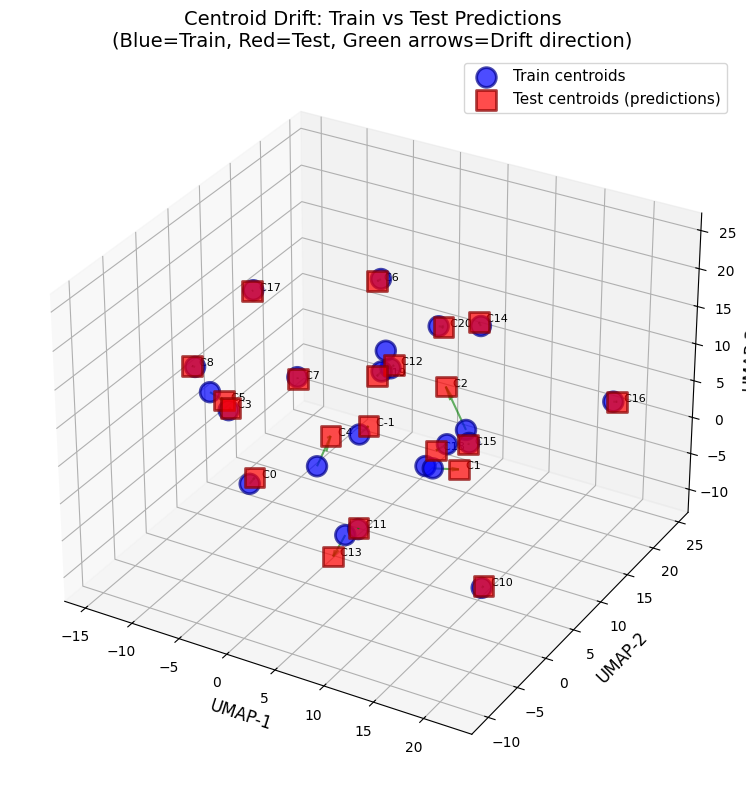

In [148]:
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

use_3d = "umap_z" in train_centroid.columns

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d") if use_3d else fig.add_subplot(111)

def get_coords(df, cluster):
    row = df.loc[cluster]
    x, y = row["umap_x"], row["umap_y"]
    z = row["umap_z"] if use_3d else None
    return (x, y, z) if use_3d else (x, y)

# Plot train centroids
tx = train_centroid["umap_x"]
ty = train_centroid["umap_y"]
tz = train_centroid["umap_z"] if use_3d else None
if use_3d:
    ax.scatter(tx, ty, tz,
               s=200, c="blue", marker="o", label="Train centroids",
               alpha=0.7, edgecolors="darkblue", linewidth=2)
else:
    ax.scatter(tx, ty, s=200, c="blue", marker="o", label="Train centroids",
               alpha=0.7, edgecolors="darkblue", linewidth=2)

# Plot test centroids
sx = test_centroid["umap_x"]
sy = test_centroid["umap_y"]
sz = test_centroid["umap_z"] if use_3d else None
if use_3d:
    ax.scatter(sx, sy, sz,
               s=200, c="red", marker="s", label="Test centroids (predictions)",
               alpha=0.7, edgecolors="darkred", linewidth=2)
else:
    ax.scatter(sx, sy, s=200, c="red", marker="s", label="Test centroids (predictions)",
               alpha=0.7, edgecolors="darkred", linewidth=2)

# Draw arrows and labels for common clusters
for cluster in common:
    tr = train_centroid.loc[cluster]
    te = test_centroid.loc[cluster]
    if use_3d:
        ax.quiver(tr["umap_x"], tr["umap_y"], tr["umap_z"],
                  te["umap_x"] - tr["umap_x"],
                  te["umap_y"] - tr["umap_y"],
                  te["umap_z"] - tr["umap_z"],
                  color="green", alpha=0.6, arrow_length_ratio=0.3)
        ax.text(te["umap_x"], te["umap_y"], te["umap_z"], f"  C{cluster}", fontsize=8)
    else:
        ax.arrow(tr["umap_x"], tr["umap_y"],
                 te["umap_x"] - tr["umap_x"], te["umap_y"] - tr["umap_y"],
                 head_width=0.15, head_length=0.1, fc="green", ec="green",
                 alpha=0.5, length_includes_head=True)
        ax.text(te["umap_x"], te["umap_y"], f"  C{cluster}", fontsize=9, ha="left")

ax.set_xlabel("UMAP-1", fontsize=12)
ax.set_ylabel("UMAP-2", fontsize=12)
if use_3d:
    ax.set_zlabel("UMAP-3", fontsize=12)
ax.set_title(
    "Centroid Drift: Train vs Test Predictions\n"
    "(Blue=Train, Red=Test, Green arrows=Drift direction)",
    fontsize=14
)
ax.legend(fontsize=11, loc="best")
if not use_3d:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Check if cluster -1 exists in both train and test predictions
print("Train clusters:", sorted(train_data["cluster"].unique()))
print("Test predicted clusters:", sorted(test_data["cluster_pred"].unique()))
print("\nCluster -1 in train:", -1 in train_data["cluster"].values)
print("Cluster -1 in test predictions:", -1 in test_data["cluster_pred"].values)


Train clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Test predicted clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Cluster -1 in train: True
Cluster -1 in test predictions: True


In [149]:
# Display cluster labels table
cluster_labels

,cluster,cluster_label,label_conf,matched_patterns,secondary_labels,severity,severity_rank
0,-1,PHP webshell deployment / backdoor probe,0.342,"0\.php, \.php$",PHPUnit RCE probing (eval-stdin.php); Generic ...,CRITICAL,0
1,0,Path traversal / directory escape probe,0.723,"\.%0e/, cgi-bin/.*bin/sh",,CRITICAL,0
2,1,Git / source code exposure scan,0.774,\.git/config,GeoServer / infrastructure admin probe; Secret...,HIGH,1
3,2,Generic login discovery / credential targeting,0.929,"/login(\.|/|$), login\.jsp, logon\.html",Cisco / VPN / firewall probe; IoT / embedded d...,MEDIUM,2
4,3,Favicon / robots.txt fingerprinting,0.784,"^/favicon\.ico$, favicon\.ico/ads\.txt, favico...",PHP webshell deployment / backdoor probe,LOW,3
5,4,Favicon / robots.txt fingerprinting,0.820,"^/favicon\.ico$, ^/robots\.txt$",,LOW,3
6,5,Favicon / robots.txt fingerprinting,0.873,"^/favicon\.ico$, ^/robots\.txt$",,LOW,3
7,6,Uncategorized / miscellaneous scanning,0.000,,,LOW,3
8,7,PHP webshell deployment / backdoor probe,0.377,"0\.php, \.php$, adminfuns\.php, class-t\.api\....",Cloud metadata / config exposure; WordPress ex...,CRITICAL,0
9,8,PHP webshell deployment / backdoor probe,0.029,"adminfuns\.php, ws\.php",Cloud metadata / config exposure,CRITICAL,0


In [ ]:
# Map cluster -> label from train
cluster_to_label = (
    train_data[["cluster", "cluster_label"]]
    .drop_duplicates()
    .set_index("cluster")["cluster_label"]
    .to_dict()
)

test_data["pred_label"] = test_data["cluster_pred"].map(cluster_to_label).fillna("Unknown / New")

test_data["pred_label"].value_counts()


pred_label
PHP webshell deployment / backdoor probe          361
IoT / embedded device exploit scan                201
Secrets discovery (.env harvesting)                68
Exchange / Autodiscover / RDP probe                67
Favicon / robots.txt fingerprinting                46
Uncategorized / miscellaneous scanning             28
Git / source code exposure scan                    27
Path traversal / directory escape probe            20
Legitimate application traffic                      6
Generic login discovery / credential targeting      3
Name: count, dtype: int64

In [ ]:
import datetime
ART = Path("Trained-model Artifacts")
ART.mkdir(exist_ok=True)

labels_train = train_data["cluster"].values

joblib.dump(hdb,          ART / "hdbscan.joblib" /datetime.datetime.now().strftime("%Y%m%d_%H%M%S")) )
joblib.dump(tfidf,        ART / "tfidf.joblib" / datetime.datetime.now().strftime("%Y%m%d_%H%M%S")) )
joblib.dump(scaler,       ART / "scaler.joblib" / datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
joblib.dump(num_cols,     ART / "num_cols.joblib" / datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
joblib.dump(X_train,      ART / "X_train.joblib" / datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
joblib.dump(labels_train, ART / "labels_train.joblib" / datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))

print("Saved: hdbscan, tfidf, scaler, num_cols, X_train, labels_train")
print(f"Path: {ART.resolve()}")

In [ ]:
nn_index = NearestNeighbors(n_neighbors=1, metric='cosine', algorithm='brute')
nn_index.fit(X_train)

joblib.dump(nn_index, ART / "nn_index.joblib")

print("Saved: nn_index")
print(f"\nAll 7 artifacts ready in: {ART.resolve()}")
print(f"X_train shape:     {X_train.shape}")
print(f"Labels (unique):   {sorted(set(labels_train))}")